## heat budget for change in OHC = change in MHT - change in F_s

In [38]:
import numpy as np
import xarray as xr
from glob import glob
import pandas as pd
from scipy import signal, stats
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

import palettable.colorbrewer as cb 

from statsmodels.tsa.stattools import ccf
from PIL import Image
import io

from process_raw_data import process_data, decimal_year_to_datetime
from stats_plots import zero_lag_corr_hf_mht, compute_n_eff_and_r_crit, parse_lat_label, plot_hovmöller, plot_timeseries

In [2]:
ds = xr.open_dataset("data/Bayesian_estimates_Atlantic_MHT_HTC_HF_OHC.nc")

In [3]:

lats = ds.latitude.values
n_lats = len(lats)
lat_labels = [f"{np.abs(lat)}{'°N' if lat > 0 else '°S'}" for lat in lats]


ds["time"] = decimal_year_to_datetime(ds.time.values)

# mht = ds.mht.isel(lat=slice(1,None)).dropna(dim="time", how="any") # drop 65
mht = ds.mht.dropna(dim="time", how="any") # drop 65
mht_mean = mht.mean(dim="posterior_samples")

mht_detrended = process_data(mht_mean, detrended=True, restore_mean=True)
mht_detrended_anom = process_data(mht_mean, detrended=True).dropna(dim="time", how="any")

# # surface heat flux

hf = ds.qnet.dropna(dim="time", how="any")
hf_mean = hf.mean(dim="posterior_samples")
hf_detrended = process_data(hf_mean, detrended=True,)
# drop first time step, since mht starts 2004-05 not 2004-02
# hf_detrended = hf_detrended.isel(time=slice(1,None))

## heat transport convergence

htc = ds.htc.dropna(dim="time", how="any")
htc_mean = htc.mean(dim="posterior_samples")
htc_detrended = process_data(htc_mean, detrended=True,)

## ocean heat content tendency
ohct = ds.ohct.dropna(dim="time", how="any")
ohct_mean = ohct.mean(dim="posterior_samples")
ohct_mean = ohct_mean.isel(time=slice(1,None))

ohct_detrended = process_data(ohct_mean, detrended=True,)
# drop first time step, since mht starts 2004-05 not 2004-02

## lats and regions
region_labels = []

for i in range(len(lats) - 1):
    lat1 = lats[i]
    lat2 = lats[i + 1]

    def fmt(lat):
        if lat > 0:
            return f"{abs(int(lat))}°N"
        elif lat < 0:
            return f"{abs(int(lat))}°S"
        else:
            return "0°"

    region_labels.append(f"{fmt(lat1)}-{fmt(lat2)}")
    
# # adapt lats to drop 65
# lats = lats[1:]  # drop 65
# lat_labels = lat_labels[1:]  # drop 65
# n_lats = len(lats)

regions = np.arange(hf_detrended.sizes["number_regions"])

region_bounds = []
for i, label in enumerate(region_labels):
    lo, hi = (parse_lat_label(b) for b in label.split("-", 1))
    region_bounds.append((lo, hi))

# regions = regions[1:]
# region_labels = region_labels[1:]

region_info = {"idx": regions, "labels": region_labels, "bounds": region_bounds}

## region of interest 16°N-5°N

In [4]:
periods = {
    "pre2009": ("2004", "2008-11"),
    "2009_2014": ("2009", "2014-11"),
    "2009_2020": ("2009", "2020"),
    # "post2014": ("2015", "2020"),
    # "total": ("2004", "2020")
}

periods_labels = {
    "pre2009": "1. Pre 2009",
    "2009_2014": "2. 2009-2014",
    "post2014": "3. Post 2014",
    "total": "Total: 2004-2020"
}

In [5]:
idx_16 = [np.where((lats == 16))[0][0]]
idx_5 = [np.where((lats == 5))[0][0]]
region_idx = [i for i, label in enumerate(region_labels) if label == "16°N-5°N"][0]

## mht
mht_16N = mht_mean.isel(lat=idx_16)
mht_5N = mht_mean.isel(lat=idx_5)
mht_region = - mht_16N + mht_5N
mht_region = mht_region.squeeze('lat', drop=True)

## htc, hf, ohct for 16°N-5°N region

htc_region = htc_mean.isel(number_regions=region_idx)  
hf_region  = hf_mean.isel(number_regions=region_idx)
ohct_region = ohct_mean.isel(number_regions=region_idx)


# mean for each period for each quantity (htc, hf, ohct) and compute residuals
rows = {}
means = {}

for period_name, (year_start, year_end) in periods.items():
    time_slice = slice(year_start, year_end)

    mht_16_p = mht_16N.sel(time=time_slice).mean(dim="time").item()
    mht_5_p = mht_5N.sel(time=time_slice).mean(dim="time").item()
    mht_p = mht_region.sel(time=time_slice).mean(dim="time").item()
    
    htc_p = htc_region.sel(time=time_slice).mean(dim="time").item()
    hf_p  = hf_region.sel(time=time_slice).mean(dim="time").item()
    ohct_p = ohct_region.sel(time=time_slice).mean(dim="time").item()

    # budget: htc = ohct - qnet  -> residual should be ~0
    residual_p = htc_p - (ohct_p - hf_p)

    means[period_name] = {
        "htc": htc_p,
        "hf": hf_p,
        "ohct": ohct_p,
        "residual": residual_p,
        "mht": mht_p,
        # "mht16": mht_16_p,
        # "mht5": mht_5_p,
    }

means_df = pd.DataFrame(means).T
print("Period means (PW):")
print(means_df)

# Compute changes relative to pre2009 baseline ( following bryden et al 2020)
baseline = "pre2009"
change_rows = {}

for period_name in periods:
    if period_name == baseline:
        continue

    d_htc = means[period_name]["htc"] - means[baseline]["htc"]
    d_hf = means[period_name]["hf"] - means[baseline]["hf"]
    d_ohct = means[period_name]["ohct"] - means[baseline]["ohct"]

    #  htc = ohct - hf  =>  d_htc = d_ohct - d_hf
    calc_d_htc = d_ohct - d_hf
    closure_error = d_htc - calc_d_htc

    # fraction (share of the actual observed change in htc)
    frac_ohct = d_ohct / d_htc if d_htc != 0 else np.nan
    frac_hf = -d_hf / d_htc if d_htc != 0 else np.nan

    change_rows[f"{baseline} -> {period_name}"] = {
        "d_htc (observed)": d_htc,
        "d_ohct": d_ohct,
        "d_hf": d_hf,
        "calculated_d_htc (ohct - hf)": calc_d_htc,
        "closure_error": closure_error,
        "frac_from_ohct": frac_ohct,
        "frac_from_hf": frac_hf,
    }

changes_df = pd.DataFrame(change_rows).T
print("\nChanges relative to baseline:")
print(changes_df)

Period means (PW):
                htc        hf      ohct      residual       mht
pre2009   -0.140964  0.127321 -0.013643  0.000000e+00 -0.140964
2009_2014 -0.142577  0.146296  0.003719  0.000000e+00 -0.142577
2009_2020 -0.140523  0.158026  0.017503  2.775558e-17 -0.140523

Changes relative to baseline:
                      d_htc (observed)    d_ohct      d_hf  \
pre2009 -> 2009_2014         -0.001613  0.017362  0.018974   
pre2009 -> 2009_2020          0.000441  0.031146  0.030705   

                      calculated_d_htc (ohct - hf)  closure_error  \
pre2009 -> 2009_2014                     -0.001613   6.938894e-18   
pre2009 -> 2009_2020                      0.000441   3.122502e-17   

                      frac_from_ohct  frac_from_hf  
pre2009 -> 2009_2014      -10.766439     11.766439  
pre2009 -> 2009_2020       70.640658    -69.640658  


In [ ]:
## mht
mht_16N = mht_mean.isel(lat=idx_16)
mht_5N = mht_mean.isel(lat=idx_5)
mht_region = - mht_16N + mht_5N
mht_region = mht_region.squeeze('lat', drop=True)

## htc, hf, ohct for 16°N-5°N region

htc_region = htc_mean.isel(number_regions=region_idx)  
hf_region  = hf_mean.isel(number_regions=region_idx)
ohct_region = ohct_mean.isel(number_regions=region_idx)


<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_4623/3064908284.py:4: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(mht_region.time, mht_region, label="$\Delta$ MHT", color=colors[0], linewidth=linewidth)


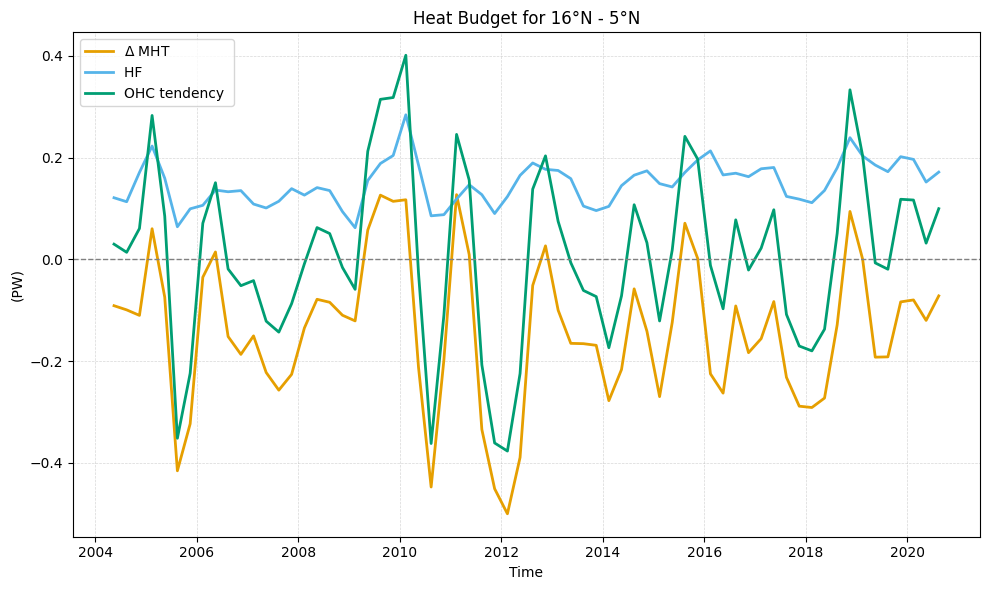

In [7]:
colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000"]
linewidth = 2.0
fig = plt.figure(figsize=(10, 6))
plt.plot(mht_region.time, mht_region, label="$\Delta$ MHT", color=colors[0], linewidth=linewidth)
# plt.plot(htc_region.time, htc_region, label="HTC", color=colors[3], linestyle="--", zorder=5, linewidth=linewidth-0.5)
plt.plot(hf_region.time, hf_region, label="HF ", color=colors[1], linewidth=linewidth)
plt.plot(ohct_region.time, ohct_region, label="OHC tendency ", color=colors[2], linewidth=linewidth)
# plt.plot(mht_region.time, mht_region + hf_region, label="MHT + HF ", color=colors[5], linestyle="--", zorder=5, linewidth=linewidth-0.5)
# plt.plot(ohc_dt_calc.time, ohc_dt_calc, label="MHT + HF ", color=colors[5], linestyle="--", zorder=5)
# plt.plot(ohc_dt_calc_htc.time, ohc_dt_calc_htc, label="HTC + HF ", color=colors[6], linestyle="-.", zorder=5)

plt.title("Heat Budget for 16°N - 5°N")
plt.xlabel("Time")
plt.ylabel("(PW)")
plt.axhline(0, color="grey", linewidth=1.0, linestyle="--")
plt.legend()
plt.grid(alpha=0.5, linestyle="--", linewidth=0.5)
plt.tight_layout()
os.makedirs("heatbudget/", exist_ok=True)
plt.savefig(f"heatbudget/16_5N_components", dpi=300, bbox_inches='tight')



In [50]:
def make_diverging_cmap(palette, n=40):
    if hasattr(palette, 'mpl_colors'):
        colors_ = palette.mpl_colors
        cmap = mcolors.LinearSegmentedColormap.from_list('custom_diverging', colors_)
    else:
        cmap = palette  # already a matplotlib Colormap (e.g. cmocean)
    return mcolors.ListedColormap(cmap(np.linspace(0, 1, n)))

cmap_corr = make_diverging_cmap(cb.diverging.RdBu_11_r)      # correlation: red-blue (conventional)
cmap_mht  = make_diverging_cmap(cb.diverging.PiYG_11_r)         # MHT anomalies
# cmap_mht = make_diverging_cmap(cmo.cm.curl)
cmap_hf   = make_diverging_cmap(cb.diverging.BrBG_11_r)         # HF anomalies



def crop_cmap(cmap, lo=0.3, hi=1.0, n=256):
    if hasattr(cmap, "mpl_colormap"):   # handles palettable objects too
        cmap = cmap.mpl_colormap
    colors = cmap(np.linspace(lo, hi, n))
    return mcolors.LinearSegmentedColormap.from_list(f"{getattr(cmap,'name','cmap')}_cropped", colors)

# cmap_cropped_lats = crop_cmap(cb.sequential.GnBu_9, lo=0.4, hi=0.8)
# cmap_cropped_lats = crop_cmap(plt.cm.cividis, lo=0.1, hi=0.5)
cmap_cropped_lats = crop_cmap(plt.cm.Greys_r, lo=0.1, hi=0.5)



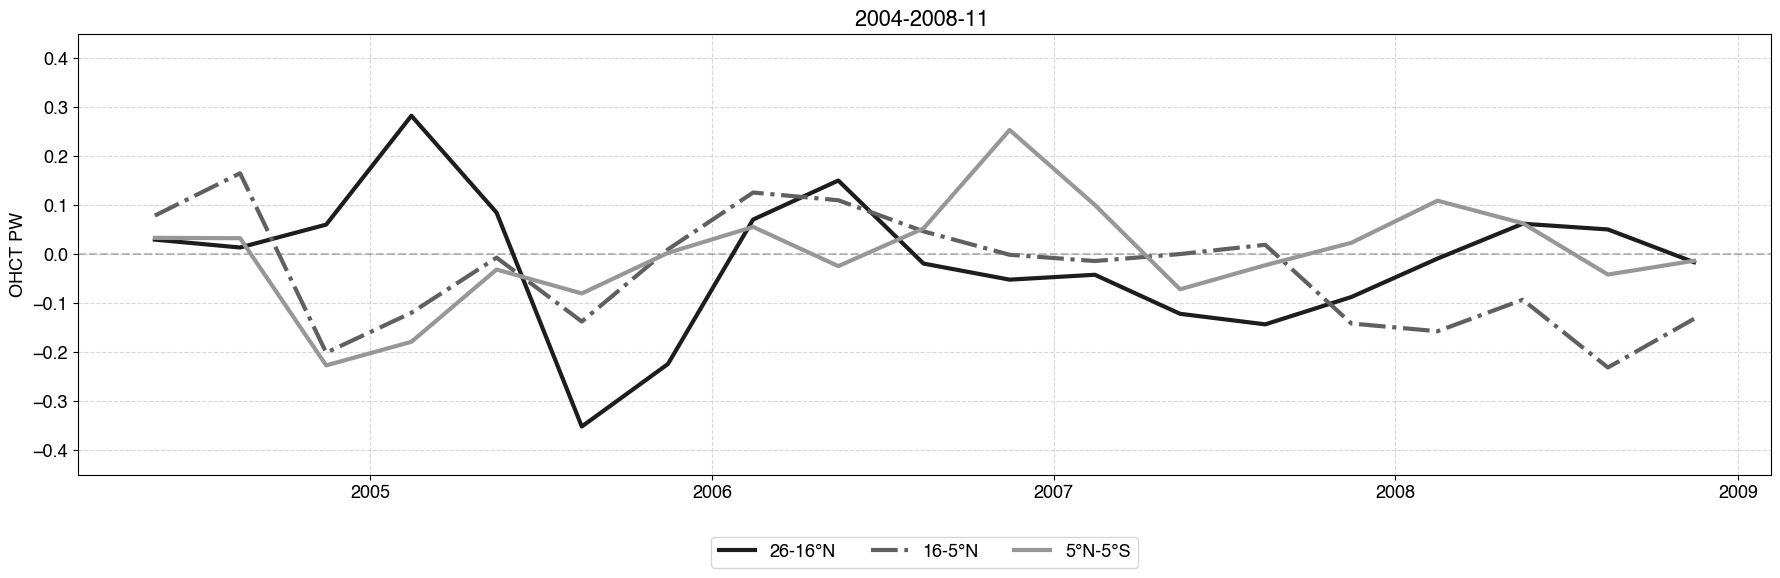

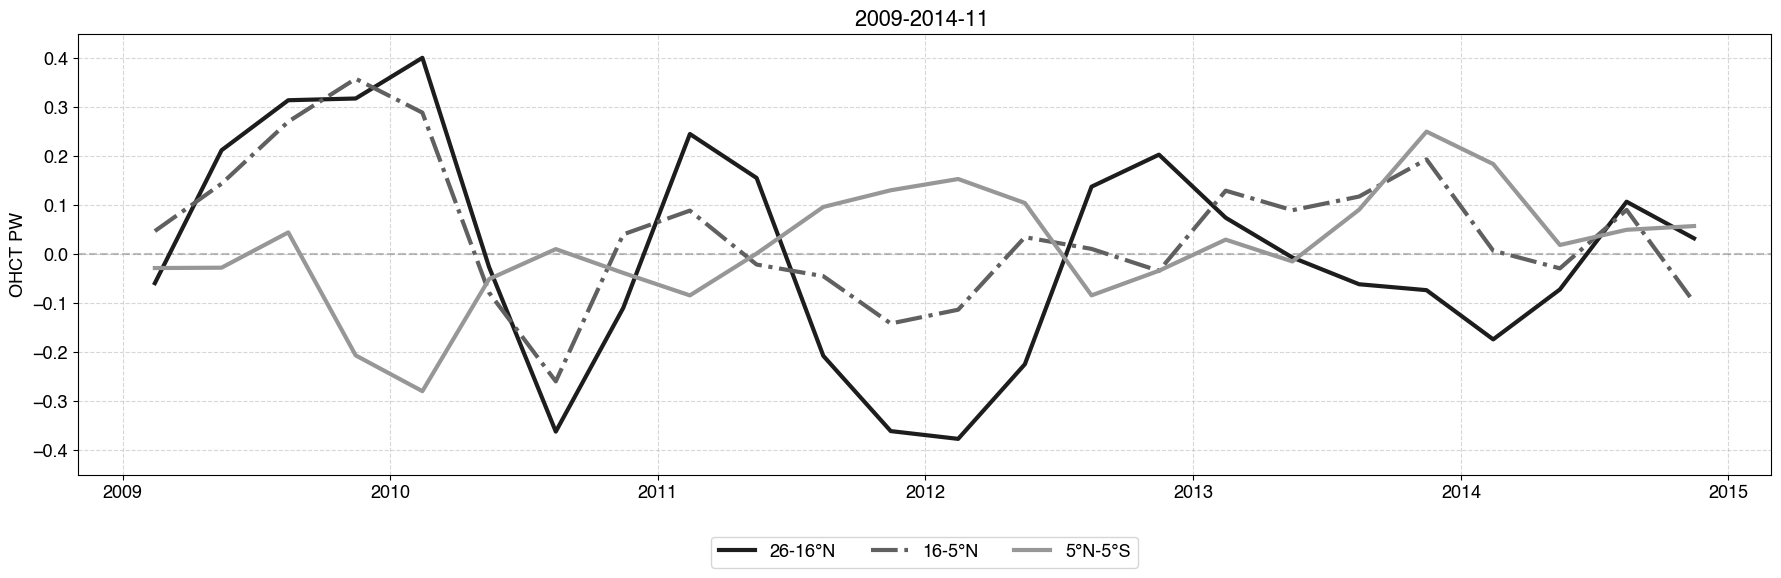

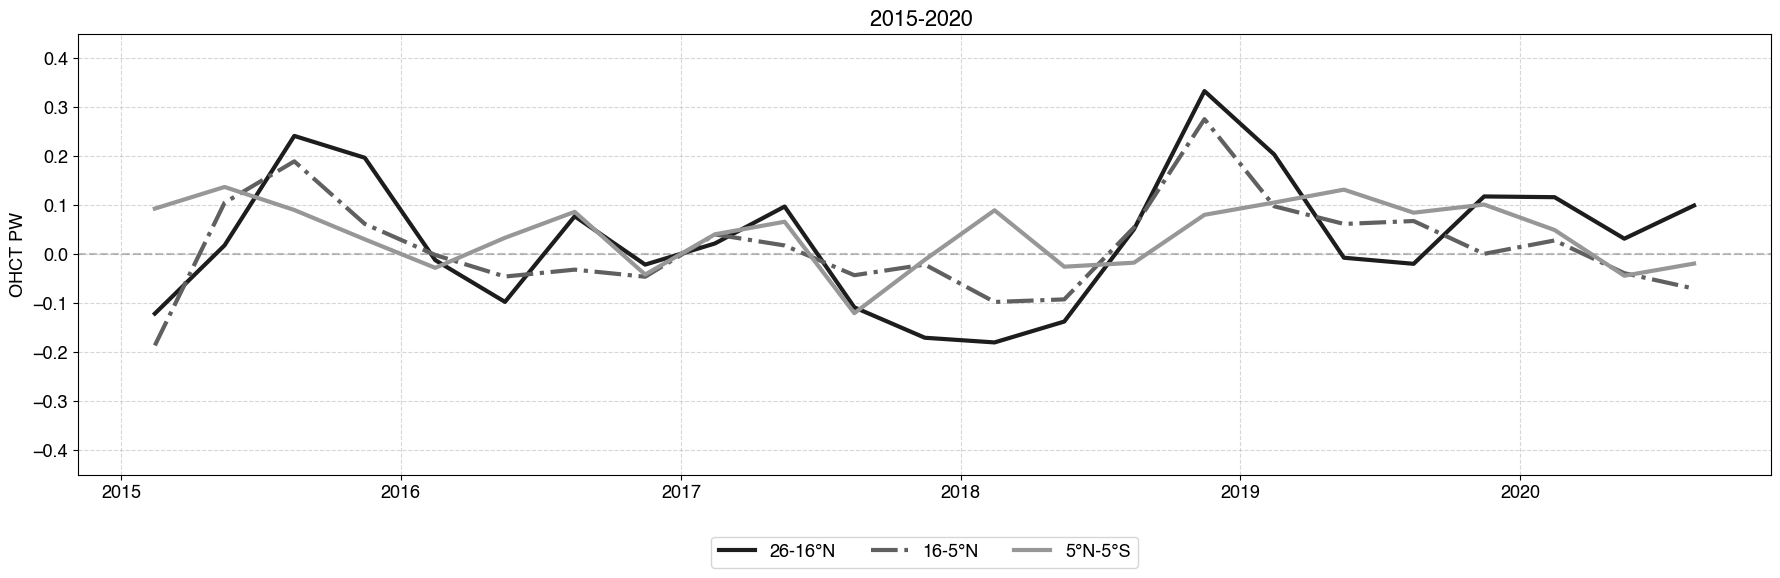

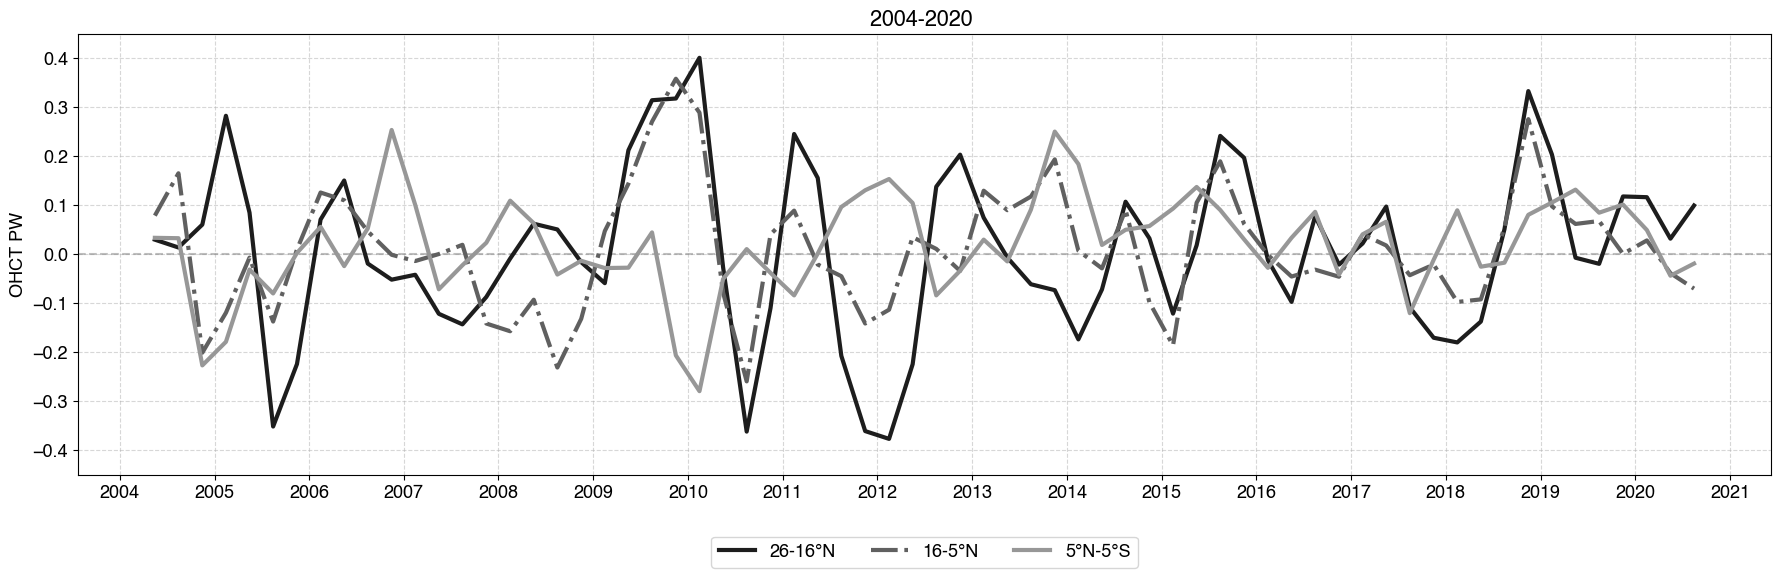

In [52]:

for period_name, (t0, t1) in periods.items():
      period_data = ohct_mean.sel(time=slice(t0, t1))

      period_26N = period_data.isel(number_regions=6).expand_dims({"lat": [0]})
      period_16 = period_data.isel(number_regions=5).expand_dims({"lat": [0]})
      period_5 = period_data.isel(number_regions=4).expand_dims({"lat": [0]})
      fig, ax = plot_timeseries(
        data={"26-16°N" : period_26N,
                "16-5°N": period_16,
                "5°N-5°S": period_5},
        lats=[0],
        all_lats=[0],
        labels=["26-16°N", "16-5°N", "5°N-5°S"],
        title=f"{t0}-{t1}",
        cmap=cmap_cropped_lats,
        label=f"",
        savefig=True,
        savelabel=f"OHCT_{period_name}",
        savefolder="timeseries/OHCT/",
        grid=True,
        ylabel="OHCT PW",
        #   linestyles={"26°N" : "-",
        #         "16°S": "-"},
          ylim=(-0.45, 0.45),
      )
    # plt.show()

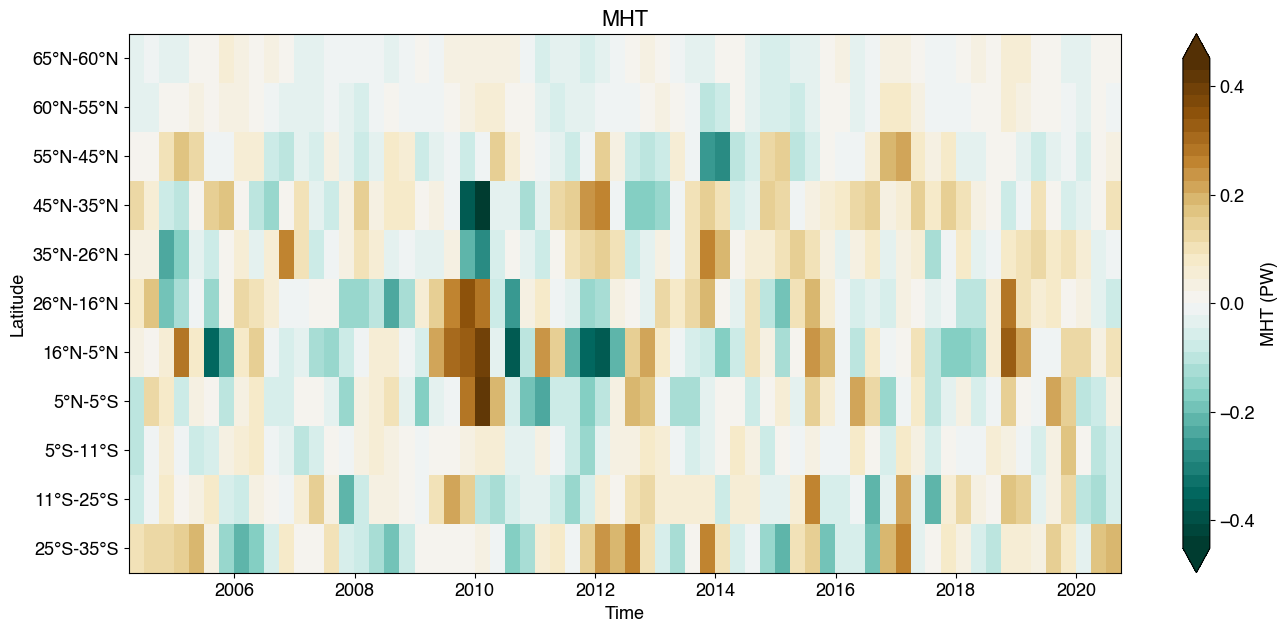

In [37]:
plot_hovmöller(
    ohct_mean,
    lats=regions,
    lat_labels=region_labels,
    anomalies=False,
    cmap=cmap_hf,
    # vlimits=(-1.4, 1.4),
    savefig=False
)

## check the periods

In [8]:
periods = {
    "pre2009": ("2004", "2008-11"),
    "2009_2014": ("2009", "2014-11"),
    "post2014": ("2015", "2020"),
    "total": ("2004", "2020")
}

periods_labels = {
    "pre2009": "1. Pre 2009",
    "2009_2014": "2. 2009-2014",
    "post2014": "3. Post 2014",
    "total": "Total: 2004-2020"
}

In [10]:
mht_change = mht_mean.isel(lat=slice(1, None)) - mht_mean.isel(lat=slice(None, -1))

mht_change = mht_change.rename({"lat": "number_regions"})
mht_change = mht_change.assign_coords(
    number_regions=hf_mean.number_regions
)


<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:42: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:42: SyntaxWarning: invalid escape sequence '\D'
/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_4623/2982260661.py:7: SyntaxWarning: invalid escape sequence '\D'
  "$\Delta$ MHT+hf": {"data": (mht_change+hf_mean).isel(number_regions=slice(1,None)), "linestyle": "-", "marker": "."},
/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_4623/2982260661.py:42: SyntaxWarning: invalid escape sequence '\D'
  if ds_name == "$\Delta$ MHT":


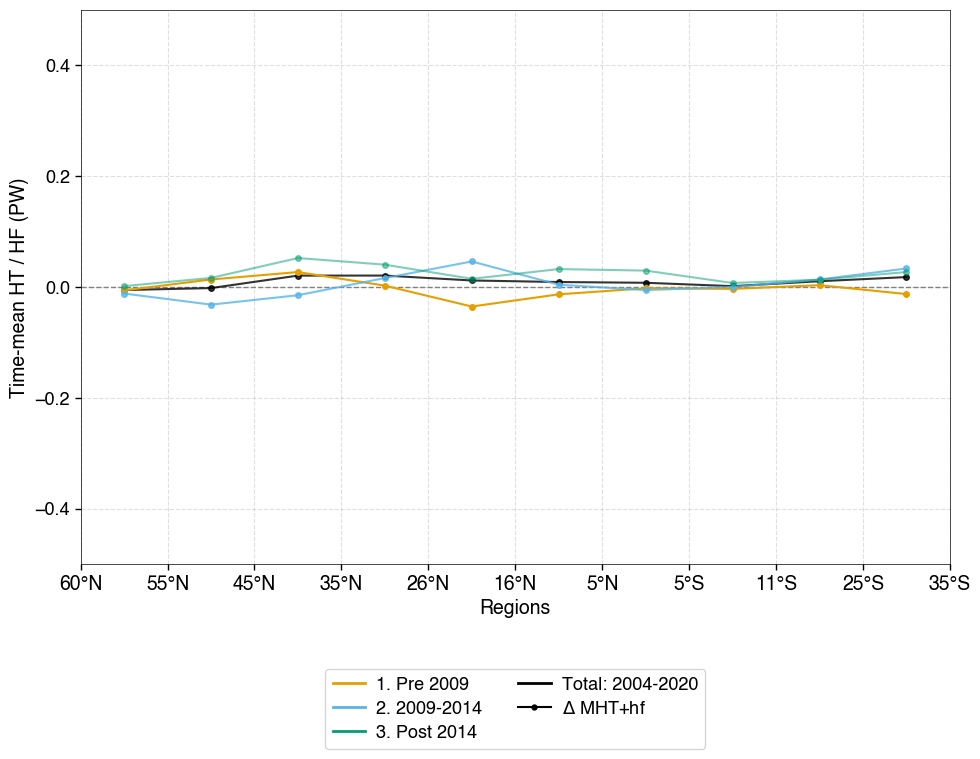

In [33]:
# SAVING = False
colors = ["#E69F00", "#56B4E9", "#009E73", "black"]

datasets = {
    # "$\Delta$ MHT": {"data": mht_change.isel(number_regions=slice(1,None)), "linestyle": "-", "marker": ".", "color":"#E69F00"},
    # "HF":  {"data": hf_mean.isel(number_regions=slice(1,None)), "linestyle": "-", "marker": "*", "color":"#56B4E9"},
    "$\Delta$ MHT+hf": {"data": (mht_change+hf_mean).isel(number_regions=slice(1,None)), "linestyle": "-", "marker": "."},
# "OHCT": {"data": ohct_mean.isel(number_regions=slice(1,None)), "linestyle": "-", "marker": "x", "color":"#009E73"},
}

# datasets = {
#     "$\Delta$ MHT-hf": {"data": (mht_change-hf_mean).isel(number_regions=slice(1,None)), "linestyle": "-", "marker": "."},
#     # "$\Delta$ MHT-ohct": {"data": mht_change-ohct_mean, "linestyle": "-", "marker": "x"},
# }

period_means = {ds_name: {} for ds_name in datasets}

fig, ax = plt.subplots(figsize=(10, 8))

plt.rcParams.update({
    "font.family": "Helvetica",
    "font.size": 13,
})
fontsize = 14

alphas = [1, 0.8, 0.5, 0.8]

for spine in ["left", "right", "top", "bottom"]:
    ax.spines[spine].set_linewidth(0.5)

x_pos = np.arange(len(lats[1:]))
# MHT: at the region boundaries
x_mht = x_pos 

# HF: shifted by half a region
x_hf = x_pos + 0.5

for ds_name, ds_info in datasets.items():
    da = ds_info["data"]
    if ds_name == "MHT":
        x = x_mht
    if ds_name == "$\Delta$ MHT":
        x = x_hf[:-1]   # drop last point to match the length of mht_change
    else:
        x = x_hf[:-1]


    for idx, (period_name, (year_start, year_end)) in enumerate(periods.items()):
        data_period = da.sel(time=slice(year_start, year_end)).mean(dim="time")
        period_means[ds_name][period_name] = data_period

        zorder = 3 if period_name == "total" else 5
    
        ax.plot(
            x,
            data_period,
            label=label,
            color=colors[idx],
            alpha=alphas[idx],
            linestyle=ds_info["linestyle"],
            marker=ds_info["marker"],
            markersize=8,
            zorder=zorder,
        )

ax.set_ylabel("Time-mean HT / HF (PW)", fontsize=fontsize)
ax.set_xlabel("Regions", fontsize=fontsize)
ax.set_ylim(-0.5, 0.5)
# ax.set_xticks(x_pos)
# ax.set_xticklabels(region_labels, fontsize=fontsize, rotation=45, ha="right")
ax.set_xticks(x_pos)

mht_latitudes = [60, 55, 45, 35, 26, 16, 5, -5, -11, -25, -35]
mht_labels = [
    "60°N", "55°N", "45°N", "35°N", "26°N",
    "16°N", "5°N", "5°S", "11°S", "25°S", "35°S"
]

ax.set_xticks(x_mht)
ax.set_xticklabels(mht_labels, fontsize=fontsize)

# ax.set_xlim(-0.5, len(region_labels) - 0.5 + 1)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.tick_params(axis="both", which="major", length=4, width=1.0)
ax.axhline(0, color="grey", linewidth=1.0, linestyle="--")

period_handles = [
    Line2D(
        [0], [0],
        color=colors[idx],
        linestyle="-",
        linewidth=2,
        label=periods_labels[period_name],
    )
    for idx, period_name in enumerate(periods)
]
dataset_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle=ds_info["linestyle"],
        marker=ds_info["marker"],
        markersize=7,
        linewidth=1.5,
        label=ds_name,
    )
    for ds_name, ds_info in datasets.items()
]

legend = ax.legend(
    handles=period_handles + dataset_handles,
    loc="lower center",
    frameon=True,
    handlelength=1.8,
    handletextpad=0.6,
    labelspacing=0.4,
    ncol=2,
    bbox_to_anchor=(0.5, -0.35),
)
plt.grid(alpha=0.4, linestyle="--")
plt.tight_layout()

if SAVING:
    os.makedirs("figures/fig8/", exist_ok=True)
    plt.savefig("figures/fig8/3periods_total_HF_MHT.pdf", dpi=300, bbox_inches="tight")
plt.show()